In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("customer 1-EDa-prj1.csv")
data

,customer_id,age,income,purchase_amount,gender,region,total_purchases,preferred_product_category,customer_loyalty_score,signup_date,last_purchase_date
0,1,56.0,67700.0,1019.145669,Female,South,31.0,Toys,12.501082,2022-05-01,2022-02-27
1,2,69.0,50200.0,252.214693,Male,North,27.0,Toys,14.402036,2022-03-14,2022-07-03
2,3,46.0,84000.0,354.742321,Male,East,25.0,Clothing,89.085761,2022-07-17,2022-04-13
3,4,32.0,42700.0,716.573913,Male,West,5.0,Electronics,98.800804,2022-07-09,2021-04-21
4,5,60.0,112300.0,1528.118235,Female,West,6.0,Clothing,28.893785,2021-04-21,2021-06-02
...,...,...,...,...,...,...,...,...,...,...,...
3521,983,42.0,37500.0,1501.071832,Male,East,16.0,Electronics,2.403770,2021-04-02,2023-07-27
3522,1078,31.0,110800.0,1042.922632,Male,East,23.0,Electronics,72.893301,2022-09-22,2023-04-25
3523,956,77.0,108600.0,1713.991224,Female,West,37.0,Electronics,23.945481,2022-08-16,2021-04-30
3524,1326,43.0,32200.0,1693.124230,Male,North,35.0,Toys,6.470420,2021-03-25,2021-11-20


# Data Quality Report:
•	Data quality checks (missing values, duplicates, outliers, anomalies etc)
•	Methods used to clean the data.


In [ ]:
data.isnull().sum()
# less no. of missing values removing rows

data1= data.dropna(axis = 0)
#data.isnull().sum()

In [ ]:
data1.shape, data.shape

((3466, 11), (3526, 11))

## customer_id-	A unique identifier for each customer.

In [ ]:
data2 = data1.drop_duplicates(subset='customer_id')
data1.shape, data2.shape

((3466, 11), (3416, 11))

## age	- The age of the customer, typically between 18 and 80 years.

In [ ]:
data3 = data2[(data2['age'] >= 18) & (data2['age'] <= 80)]
data2.shape, data3.shape

((3416, 11), (3406, 11))

## income-	Annual income of the customer, rounded to the nearest 100. Ranges between 20,000 and 120,000.

In [ ]:
data3['income_rounded'] = data3['income'].round(-2)
#data['income_rounded'].unique()

/tmp/ipython-input-3330653769.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data3['income_rounded'] = data3['income'].round(-2)


In [ ]:
data4 = data3[(data3['income_rounded'] >= 20000) & (data3['income_rounded'] <= 120000)]
data3.shape, data4.shape

((3406, 12), (3396, 12))

## purchase_amount-	The most recent purchase amount (currency) made by the customer , typically between 20 and 2,000.

In [ ]:
data5 = data4[(data4['purchase_amount'] >= 20) & (data4['purchase_amount'] <= 2000)]
data4.shape, data5.shape

((3396, 12), (3376, 12))

## gender-	The gender of the customer, either 'Male' or 'Female'

In [ ]:
data6 = data5[(data5['gender'] == "Male") | (data5['gender'] == "Female") ]
data5.shape, data6.shape

((3376, 12), (3367, 12))

## region	The geographic region where the customer is located. One of 'North', 'South', 'East', 'West'.

In [ ]:
data7 = data6[data6['region'].isin(['North', 'South', 'East', 'West']) ]
data6.shape, data7.shape

((3367, 12), (3357, 12))

## total_purchases	The total number of purchases made by the customer, typically between 1 and 50.

In [ ]:
data8 = data7[(data7['total_purchases'] >= 1) & (data7['total_purchases'] <= 50)]
data7.shape, data8.shape

((3357, 12), (3347, 12))

## preferred_product_category	The customer's favorite product category. One of 'Electronics', 'Clothing', 'Home & Garden', 'Toys', 'Health'.

In [ ]:
data9 = data8[data8['preferred_product_category'].isin(['Electronics', 'Clothing', 'Home & Garden', 'Toys', 'Health']) ]
data8.shape, data9.shape

((3347, 12), (3339, 12))

## customer_loyalty_score	A loyalty score assigned to each customer based on their behavior, ranging from 0 to 100.

In [ ]:
data10 = data9[(data9['customer_loyalty_score'] >= 0) & (data9['customer_loyalty_score'] <= 100)]
data9.shape, data10.shape

((3339, 12), (3319, 12))

## signup_date	The date when the customer signed up for the service, typically between 2021-01-01 and 2022-12-31.

In [ ]:
data10['signup_date_formatted'] = pd.to_datetime(data10['signup_date'], errors='coerce')
data10['signup_date_formatted'].dtype

/tmp/ipython-input-2216365944.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data10['signup_date_formatted'] = pd.to_datetime(data10['signup_date'], errors='coerce')


dtype('<M8[ns]')

In [ ]:
data10['signup_date_formatted'].min(), data10['signup_date_formatted'].max()

(Timestamp('2021-01-01 00:00:00'), Timestamp('2022-12-31 00:00:00'))

In [ ]:
data11 = data10[
    (data10['signup_date_formatted'] >= pd.Timestamp('2021-01-01')) &
    (data10['signup_date_formatted'] <= pd.Timestamp('2022-12-31'))
]

In [ ]:
data11['signup_date_formatted'].min(), data11['signup_date_formatted'].max()

(Timestamp('2021-01-01 00:00:00'), Timestamp('2022-12-31 00:00:00'))

In [ ]:
data11.shape

(3319, 13)

## last_purchase_date	The date when the customer made their last purchase, typically after signup_date.

In [ ]:
data11['last_purchase_date_formatted'] = pd.to_datetime(data11['last_purchase_date'], errors='coerce')
data11['last_purchase_date_formatted'].dtype

dtype('<M8[ns]')

In [ ]:
data11['last_purchase_date_formatted'].min(), data11['last_purchase_date_formatted'].max()

(Timestamp('2021-01-01 00:00:00'), Timestamp('2023-12-31 00:00:00'))

In [ ]:
data12 = data11[data11['last_purchase_date_formatted']> data11['signup_date_formatted']]
data12.shape, data11.shape

((2220, 14), (3319, 14))

In [ ]:
data12.to_csv("cleaned_data.csv")

# •	Exploratory Data Analysis (EDA) Report:
•	Descriptive Statistics: Provide basic descriptive statistics for numerical as well as categorical features and derive insights

In [ ]:
df = data12.copy()
df

,customer_id,age,income,purchase_amount,gender,region,total_purchases,preferred_product_category,customer_loyalty_score,signup_date,last_purchase_date,income_rounded,signup_date_formatted,last_purchase_date_formatted
1,2,69.0,50200.0,252.214693,Male,North,27.0,Toys,14.402036,2022-03-14,2022-07-03,50200.0,2022-03-14,2022-07-03
4,5,60.0,112300.0,1528.118235,Female,West,6.0,Clothing,28.893785,2021-04-21,2021-06-02,112300.0,2021-04-21,2021-06-02
5,6,25.0,62000.0,1024.023200,Male,West,5.0,Home & Garden,14.360273,2021-11-18,2023-07-06,62000.0,2021-11-18,2023-07-06
6,7,78.0,90500.0,1283.045712,Female,East,27.0,Home & Garden,48.221228,2022-06-11,2023-02-01,90500.0,2022-06-11,2023-02-01
7,8,38.0,81000.0,1970.645619,Male,East,8.0,Clothing,70.952806,2021-06-26,2022-12-21,81000.0,2021-06-26,2022-12-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3466,3467,39.0,43200.0,1022.574095,Female,North,34.0,Toys,13.352897,2022-03-21,2022-09-04,43200.0,2022-03-21,2022-09-04
3467,3468,25.0,23800.0,1943.602386,Male,West,4.0,Health,23.179639,2022-03-29,2022-12-23,23800.0,2022-03-29,2022-12-23
3470,3471,34.0,80400.0,465.975007,Male,South,3.0,Electronics,13.268861,2021-03-07,2023-07-29,80400.0,2021-03-07,2023-07-29
3471,3472,77.0,64400.0,1369.291029,Female,South,35.0,Home & Garden,73.795857,2022-02-09,2023-09-05,64400.0,2022-02-09,2023-09-05


In [ ]:
df.describe()

,customer_id,age,income,purchase_amount,total_purchases,customer_loyalty_score,income_rounded,signup_date_formatted,last_purchase_date_formatted
count,2220.000000,2220.000000,2220.000000,2220.000000,2220.000000,2220.000000,2220.000000,2220,2220
mean,1745.137838,48.309910,70296.576577,1001.993272,24.658108,49.838757,70296.576577,2021-11-03 19:19:47.027027200,2022-12-02 02:38:16.216216064
min,2.000000,18.000000,20200.000000,20.369326,1.000000,0.085729,20200.000000,2021-01-01 00:00:00,2021-01-22 00:00:00
25%,872.750000,33.000000,44575.000000,526.563855,13.000000,24.578672,44575.000000,2021-05-09 18:00:00,2022-06-06 00:00:00
50%,1742.500000,48.000000,70000.000000,1003.636322,24.000000,49.785463,70000.000000,2021-10-13 00:00:00,2022-12-30 00:00:00
75%,2631.250000,64.000000,96300.000000,1496.388319,37.000000,74.498006,96300.000000,2022-04-14 06:00:00,2023-07-05 00:00:00
max,3475.000000,79.000000,120000.000000,1999.508096,49.000000,99.935293,120000.000000,2022-12-31 00:00:00,2023-12-31 00:00:00
std,1006.335888,17.767498,28989.099861,570.196144,14.236139,28.778469,28989.099861,NaN,NaN


## •	Univariate Analysis: Visualizations (histograms, box plots, count plots etc) for each variable.


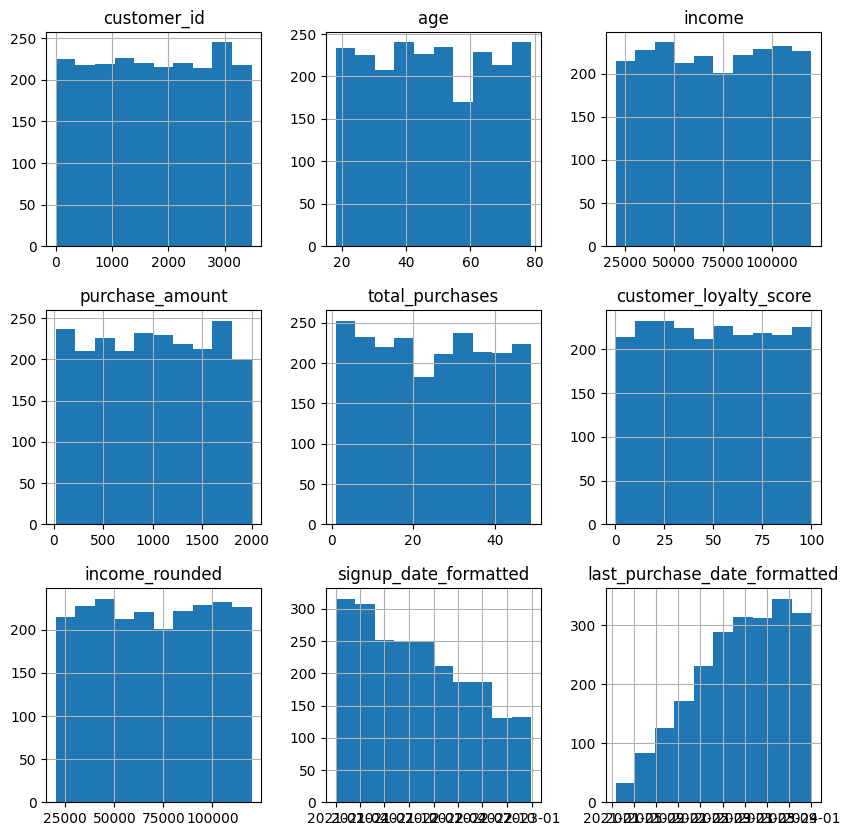

In [ ]:
# Histograms
df.hist(figsize=(10, 10))
plt.show()

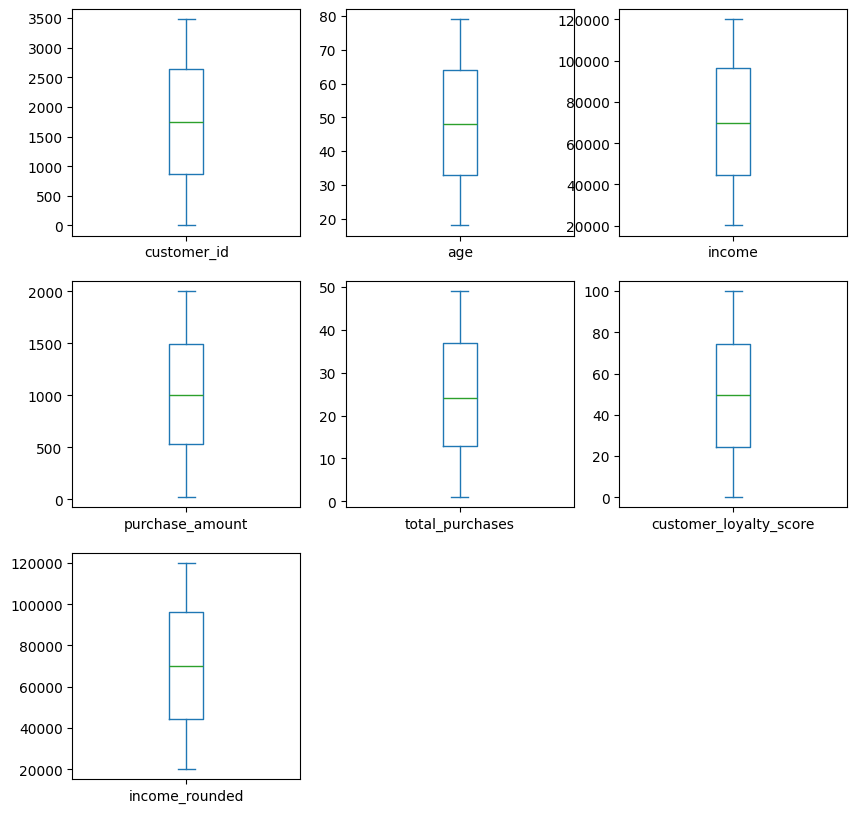

In [ ]:
#Box plots
df.plot(kind='box', subplots=True, layout=(3, 3), figsize=(10, 10))
plt.show()

## •	Bivariate Analysis: Analyze relationships between two variables, such as age vs gender, income vs. purchase_amount, or customer_loyalty_score vs. total_purchases

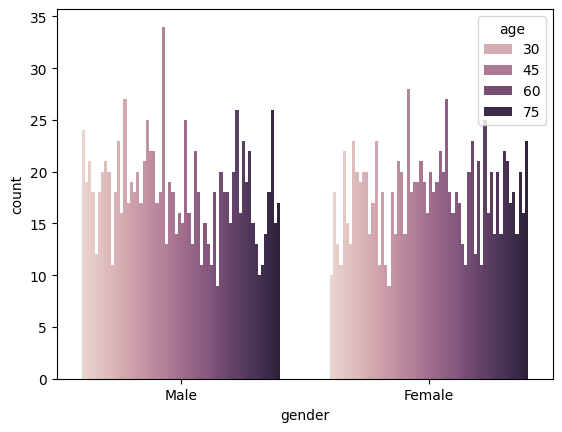

In [ ]:
# age vs gender
sns.countplot(x='gender', hue='age', data=df)
plt.show()

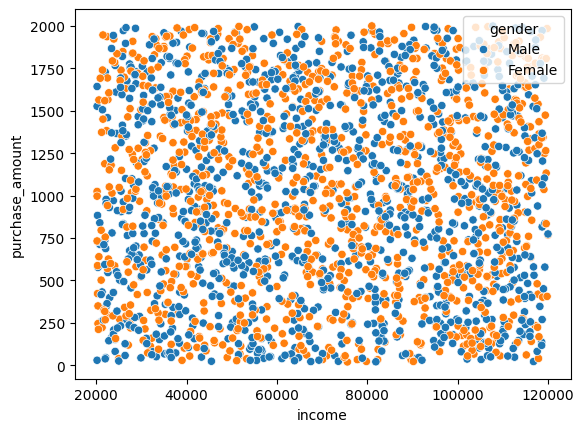

In [ ]:
# income vs. purchase_amount
sns.scatterplot(x='income', y='purchase_amount',  hue = 'gender', data=df)
plt.show()

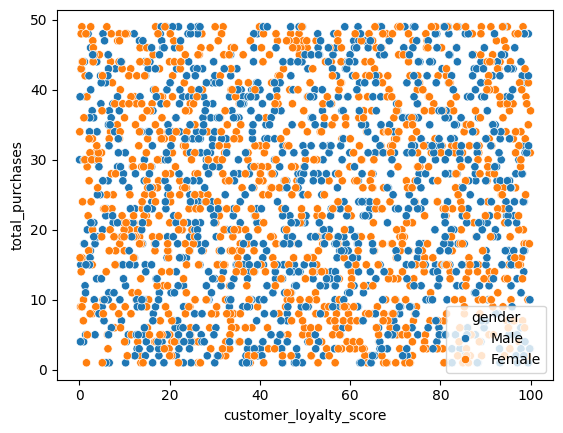

In [ ]:
# customer_loyalty_score vs. total_purchases
sns.scatterplot(x='customer_loyalty_score', y='total_purchases', hue = 'gender', data=df)
plt.show()

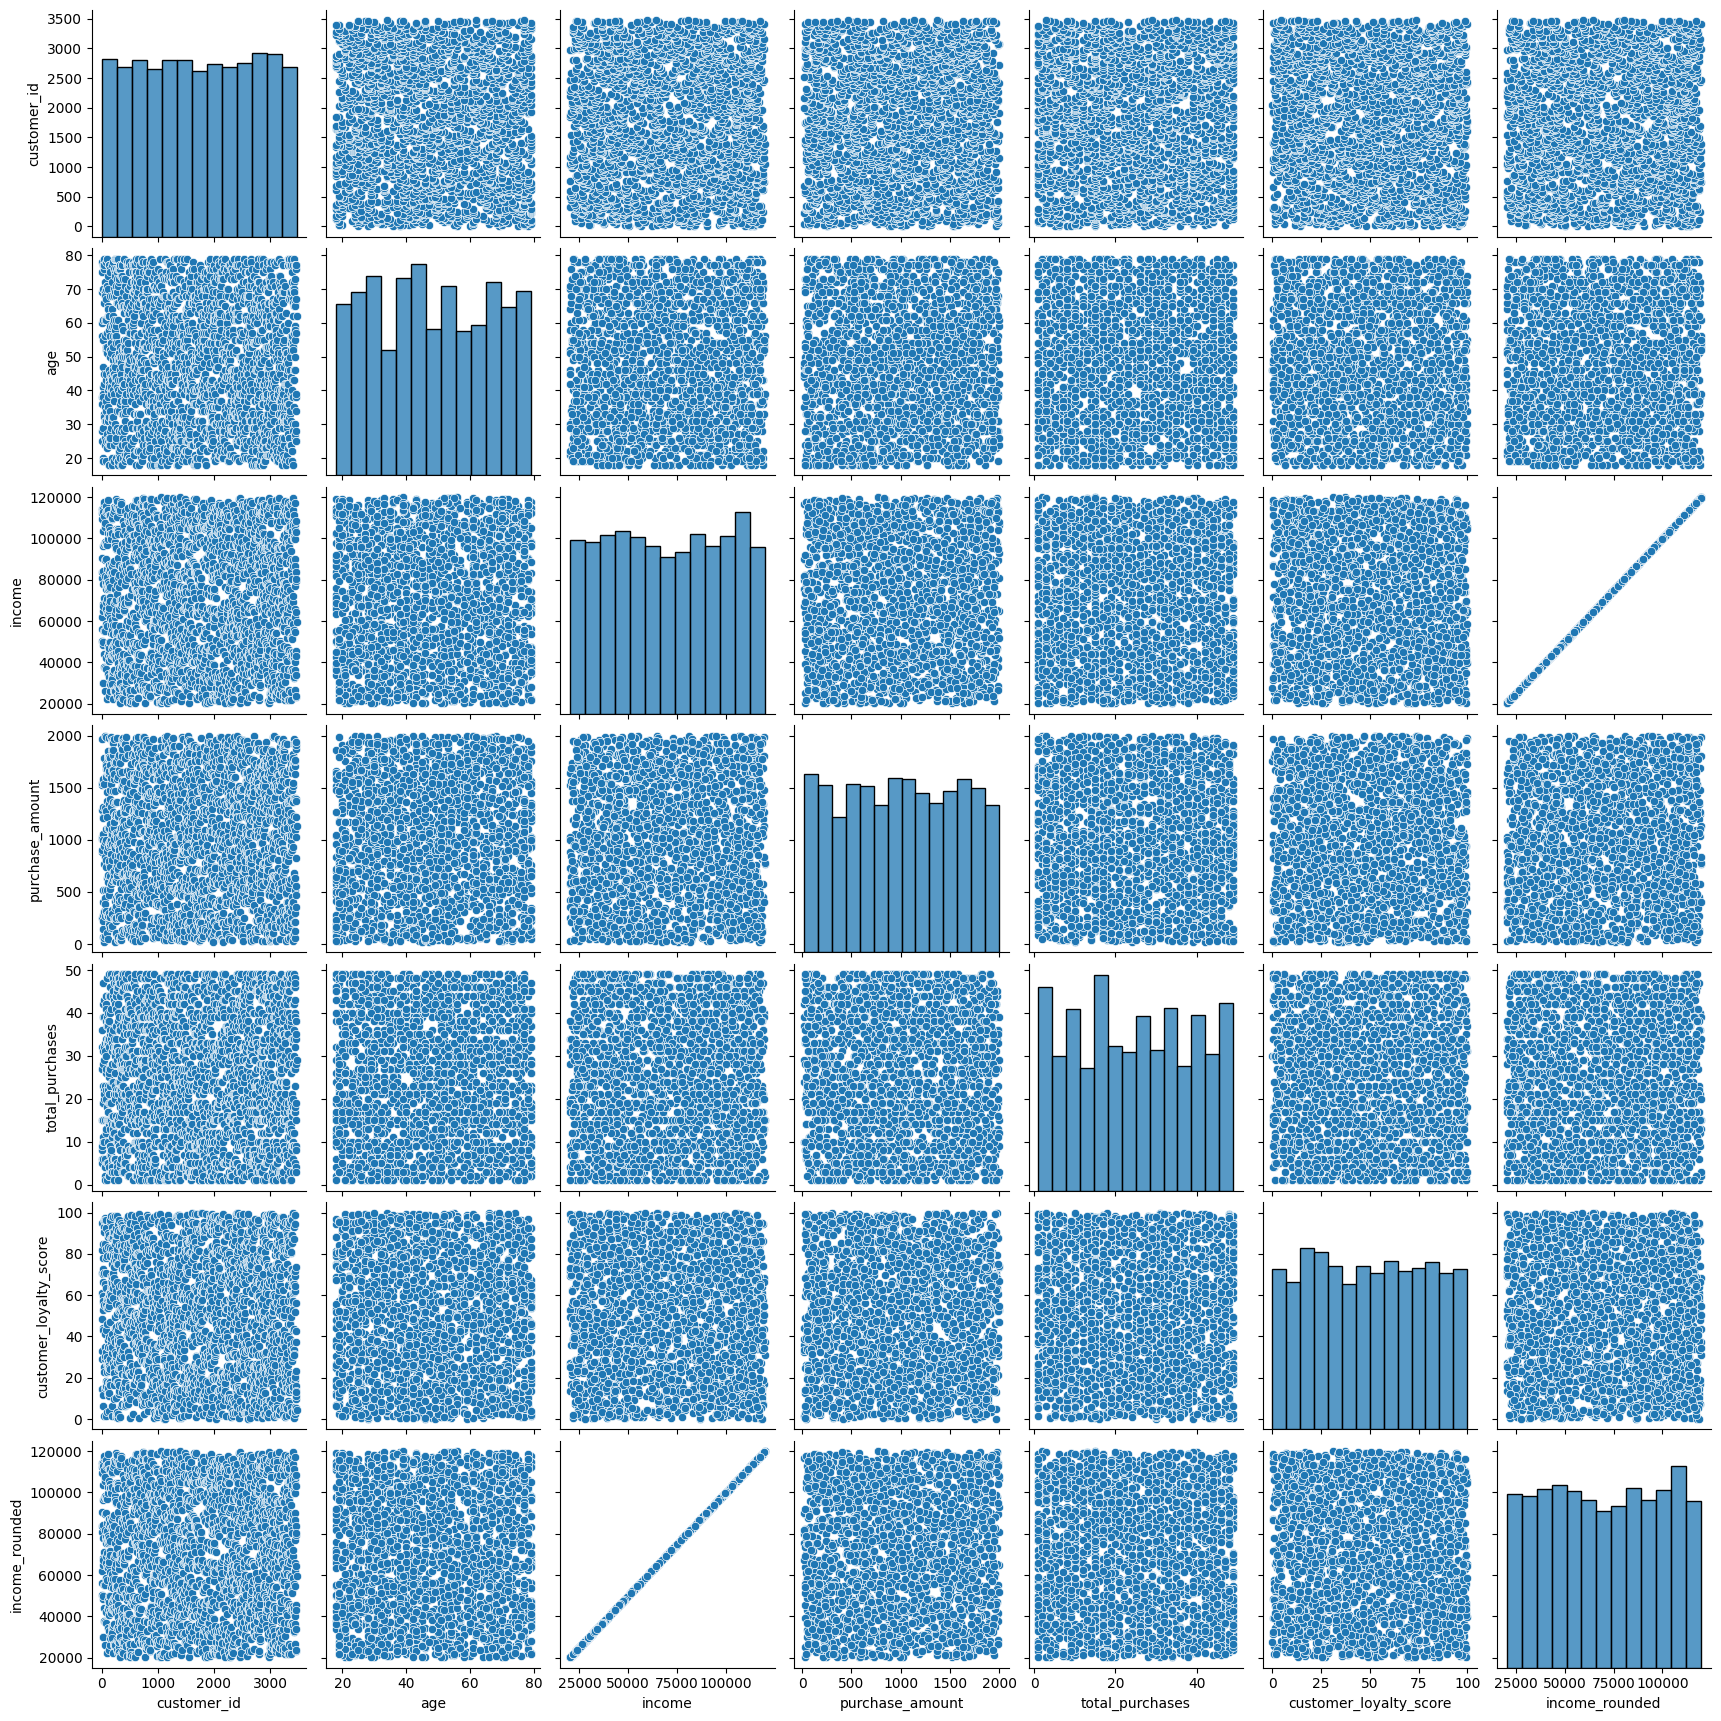

In [ ]:
sns.pairplot(df)

## •	Multivariate Analysis: Analyze relationship between two or more variables and insights from the same

In [ ]:
df['purchase_amount_by_income'] = df['purchase_amount'] / df['income']

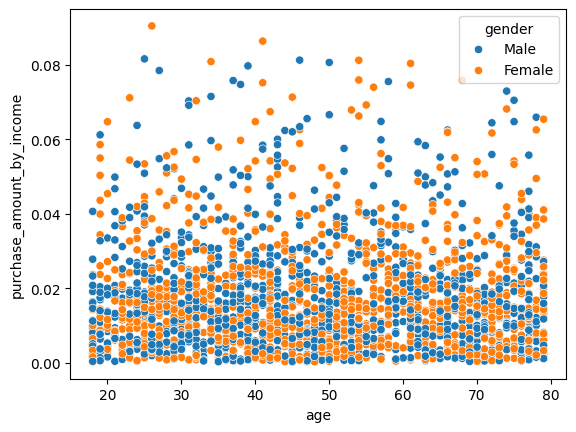

In [ ]:
sns.scatterplot(x='age', y='purchase_amount_by_income', hue = 'gender', data=df)
plt.show()

## •	Correlation Analysis: Analyze the correlation between numerical variables using correlation matrices and heatmaps.

<Axes: >

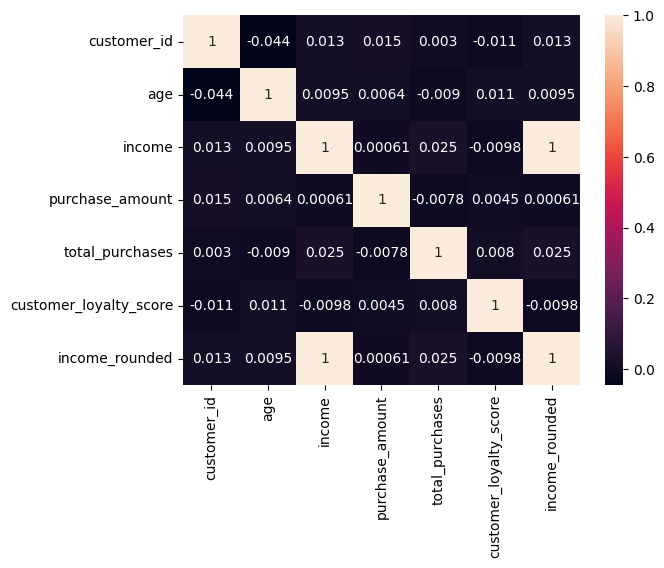

In [ ]:
df_num = df.select_dtypes(include=['int64', 'float64'])
df_num.corr()
sns.heatmap(df_num.corr(), annot=True)

## •	Time-Based Analysis: Visualize trends over time, like signups per month or last purchase dates.

In [ ]:
## signups per month
df['signup_year'] = df['signup_date_formatted'].dt.year

,purchase_amount
signup_year,
2021,1.371694e+06
2022,8.527315e+05


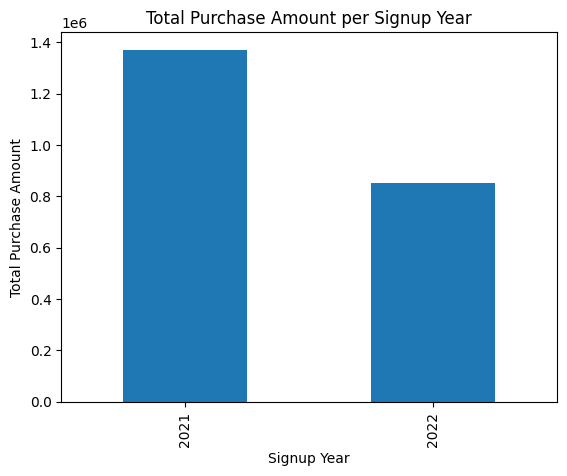

In [ ]:
df.groupby("signup_year")["purchase_amount"].sum().plot(
    kind='bar',
    title='Total Purchase Amount per Signup Year',
    xlabel='Signup Year',
    ylabel='Total Purchase Amount'
)
plt.show()

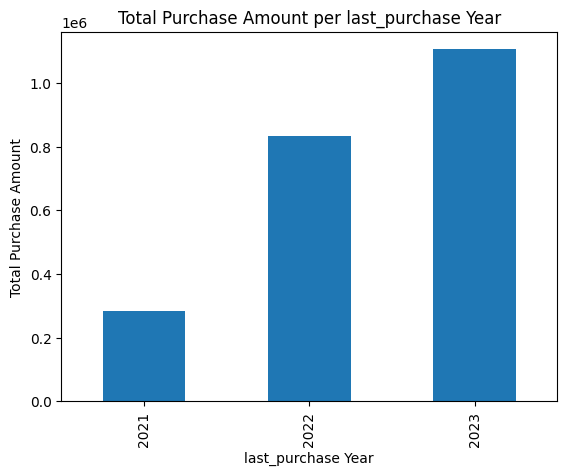

In [ ]:
df['last_purchase_year'] = df['last_purchase_date_formatted'].dt.year
df.groupby("last_purchase_year")["purchase_amount"].sum().plot(
    kind='bar',
    title='Total Purchase Amount per last_purchase Year',
    xlabel='last_purchase Year',
    ylabel='Total Purchase Amount'
)
plt.show()

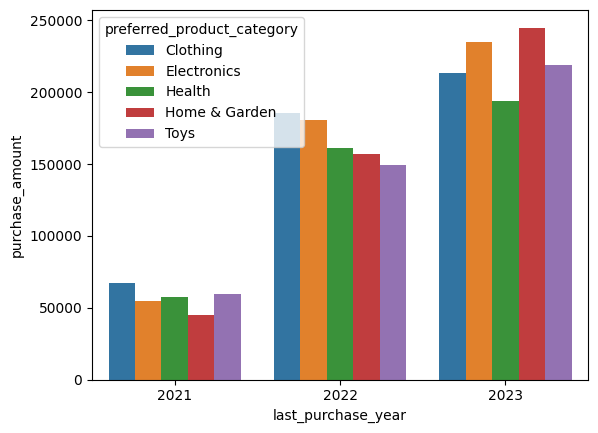

In [ ]:
grouped = df.groupby(["preferred_product_category", "last_purchase_year"])["purchase_amount"].sum().reset_index()

sns.barplot(
    data=grouped,
    x='last_purchase_year',
    y='purchase_amount',
    hue='preferred_product_category',
    palette='tab10'
)

plt.show()

In [ ]:
grouped['year_total'] = grouped.groupby('last_purchase_year')['purchase_amount'].transform('sum')
grouped['percent_of_year'] = (grouped['purchase_amount'] / grouped['year_total']) * 100

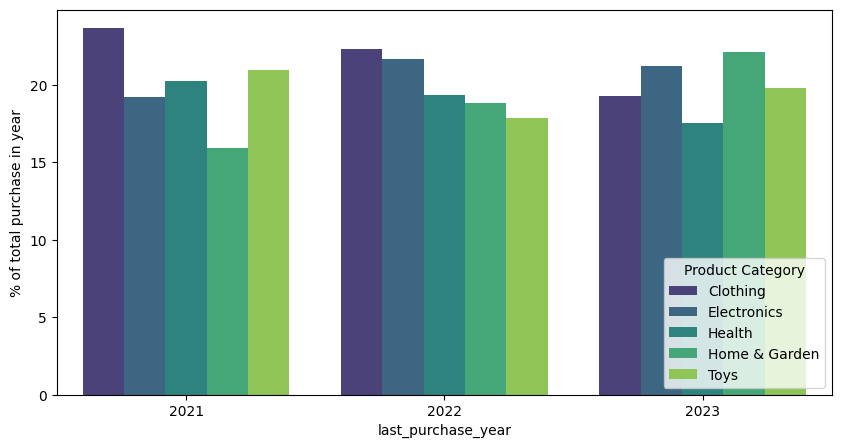

In [ ]:

plt.figure(figsize = (10,5))
sns.barplot(
    data=grouped,
    x='last_purchase_year',
    y='percent_of_year',
    hue='preferred_product_category',
    palette='viridis'
)
plt.ylabel("% of total purchase in year")

plt.legend(
    title="Product Category",
    loc='lower right',
)

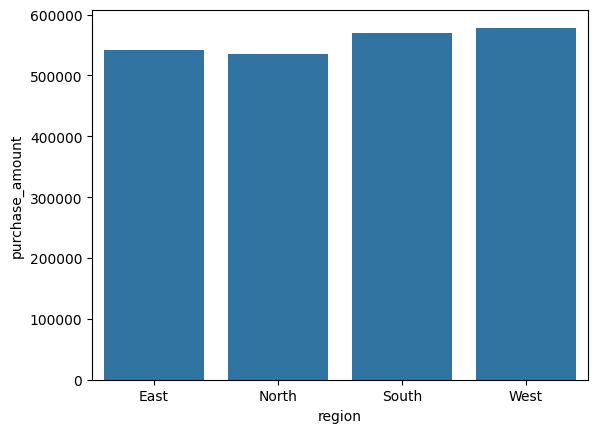

In [ ]:
grouped2 = df.groupby("region")["purchase_amount"].sum().reset_index()

sns.barplot(
    data=grouped2,
    x='region',
    y='purchase_amount',
)

plt.show()

<Axes: xlabel='customer_loyalty_score', ylabel='Count'>

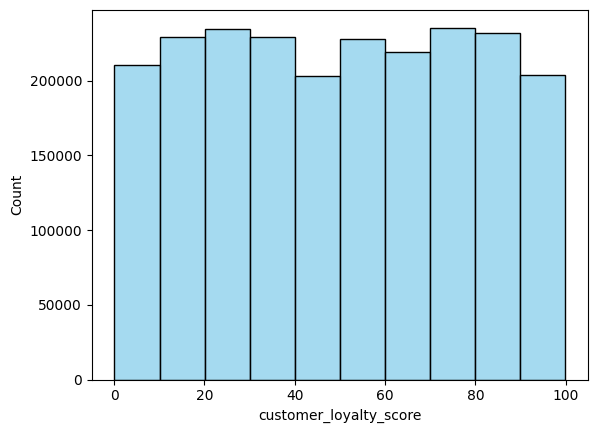

In [ ]:
# customer_loyalty_score (bins) vs purchase amount (sum)
sns.histplot(
    data=df,
    x='customer_loyalty_score',
    weights='purchase_amount',   # weight bars by purchase amount
    bins=10,                     # equal bins
    kde=False,
    color='skyblue'
)

<Axes: xlabel='age', ylabel='Count'>

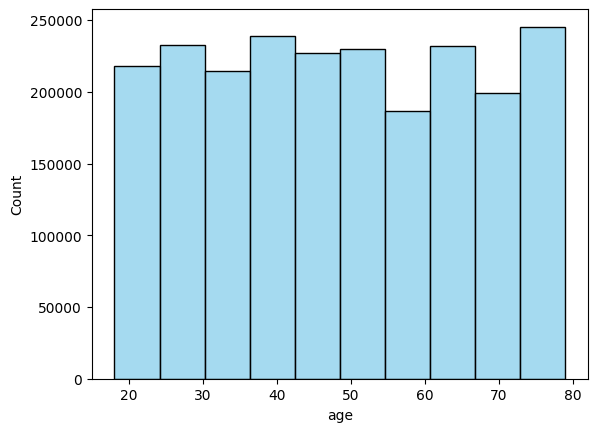

In [ ]:
# age (bins) vs purchase amount (sum)
sns.histplot(
    data=df,
    x='age',
    weights='purchase_amount',   # weight bars by purchase amount
    bins=10,                     # equal bins
    kde=False,
    color='skyblue'
)

## identify region wise in which product more purchase is there

In [ ]:
grouped3 = df.groupby(["region", "preferred_product_category"])["purchase_amount"].sum().reset_index()

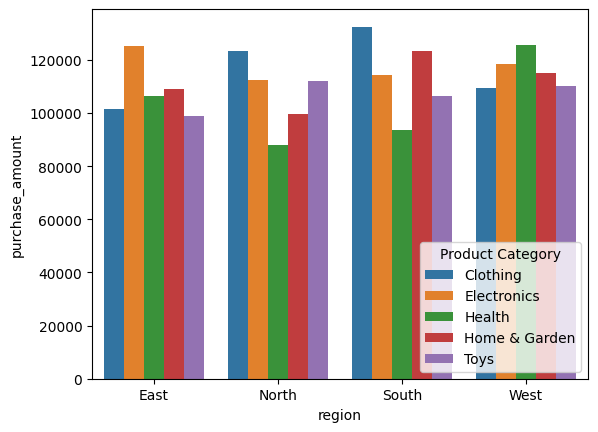

In [ ]:

sns.barplot(
    data=grouped3,
    x='region',
    y='purchase_amount',
    hue='preferred_product_category',
    palette='tab10'
)

plt.legend(
    title="Product Category",
    loc='lower right',
)

plt.show()

## identify region wise in which year more purchase is there

In [ ]:
grouped4 = df.groupby(["region", "last_purchase_year"])["purchase_amount"].sum().reset_index()

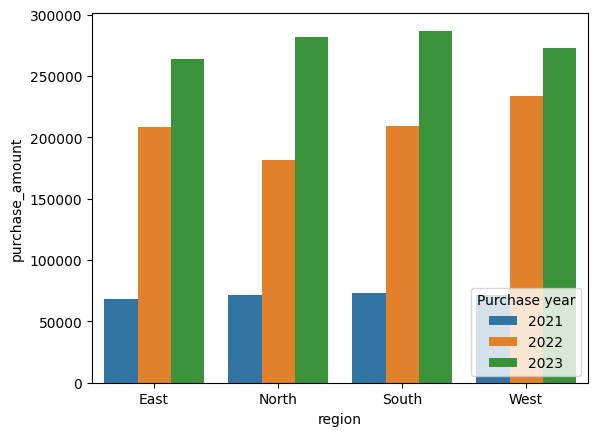

In [ ]:
sns.barplot(
    data=grouped4,
    x='region',
    y='purchase_amount',
    hue='last_purchase_year',
    palette='tab10'
)

plt.legend(
    title="Purchase year",
    loc='lower right',
)

plt.show()

## Which region has more income

In [96]:
grouped5 = df.groupby(["region", "gender"])["income_rounded"].mean().reset_index()
grouped5

,region,gender,income_rounded
0,East,Female,72390.151515
1,East,Male,68546.240602
2,North,Female,71100.367647
3,North,Male,67578.181818
4,South,Female,70206.792453
5,South,Male,70004.982206
6,West,Female,71758.862876
7,West,Male,70666.778523


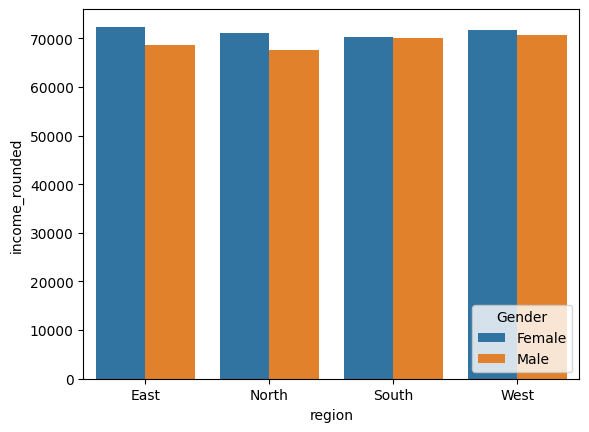

In [97]:
sns.barplot(
    data=grouped5,
    x='region',
    y='income_rounded',
    hue='gender',
    palette='tab10'
)

plt.legend(
    title="Gender",
    loc='lower right',
)

plt.show()